In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Define class of positional encoding
class PositionalEncoding:
    def __init__(self, model, max_len=5000):
        self.model = model
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, model, 2) * (-np.log(10000.0) / model))
        self.pe = torch.zeros(max_len, model)
        self.pe[:, 0::2] = torch.sin(position * div_term)
        self.pe[:, 1::2] = torch.cos(position * div_term)

In [ ]:
# Generate positional encoding
model = 64
pe = PositionalEncoding(model=model).pe
pos_range = 50
pe_vis = pe[:pos_range, :].numpy()

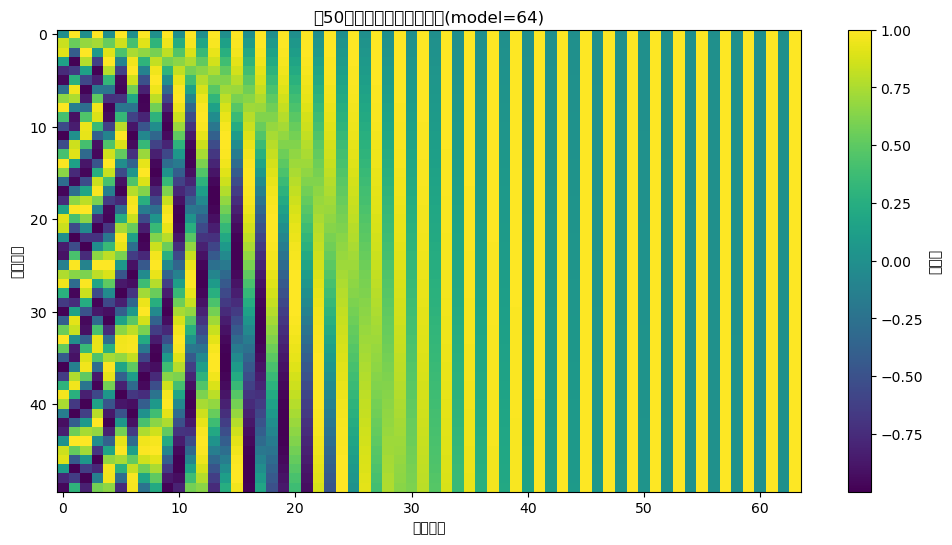

In [15]:
# Visualization
plt.figure(figsize=(12,6))
plt.imshow(pe_vis, cmap='viridis', aspect='auto')
plt.xlabel('维度索引')
plt.ylabel('位置索引')
plt.title(f'前{pos_range}个位置的位置编码向量(model={model})')
plt.colorbar(label='编码值')
plt.show()

In [16]:
# Calculate similarity of positional encoding
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(pe_vis)

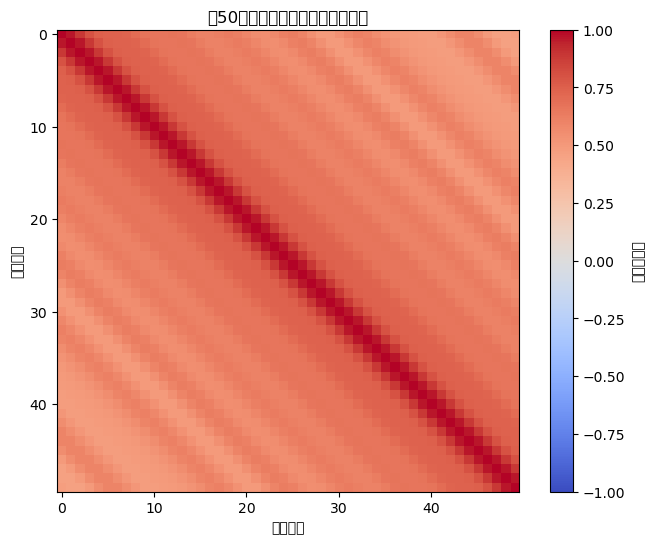

In [19]:
plt.figure(figsize=(8, 6))
plt.imshow(similarity_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.xlabel("位置索引")
plt.ylabel("位置索引")
plt.title("前50个位置编码的余弦相似度矩阵")
plt.colorbar(label="余弦相似度")
plt.show()